# Seleção de modelos e regularização $(L2)$

## Importações iniciais

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error

Como para $\lambda=0$, O modelo $Ridge$ é igual à regressão linear, então só precisamos importar $Ridge$

## Separação do dataset

In [2]:
X, y = load_diabetes(return_X_y=True,as_frame=True,scaled=True)

In [3]:
display(X,y)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

## Teste para o knn regressor com diferentes valores de $k$

In [5]:
knn = KNeighborsRegressor(metric="euclidean")

Considere $k=1,2,...,n$

In [6]:
n = 10 # n inicial

In [7]:
k = list(range(n+1))
k.remove(0)

paramsknn = {
    "n_neighbors": k
}

In [8]:
#Instanciando o grid search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=paramsknn,
    cv = 5 #Nº de folds
)

In [9]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(metric='euclidean'),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]})

Como podemos ver, o melhor parâmetro de $k$ para o dataset foi $k=10$, escolhido via grid search

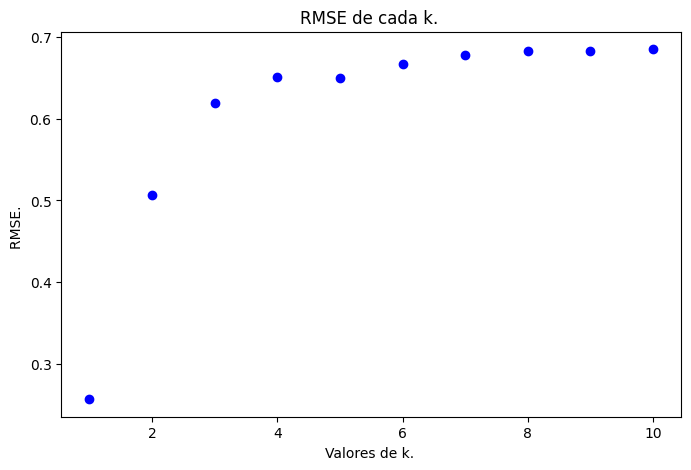

In [10]:
plt.figure(figsize=(8,5))
plt.xlabel("Valores de k. ")
plt.ylabel("RMSE. ")
plt.title("RMSE de cada k. ")
plt.scatter(grid_search.cv_results_["param_n_neighbors"],np.sqrt(grid_search.cv_results_["mean_test_score"]),label="RMSE médio de cada k.", color="blue")
plt.show()

In [11]:
grid_search.best_params_

{'n_neighbors': 10}

In [12]:
y_pred = grid_search.predict(X_test)

In [13]:
rmseknn = root_mean_squared_error(y_test,y_pred)
print(f"RMSE do KNN: {rmseknn:.2f}") #RMSE do melhor modelo encontrado no grid search

RMSE do KNN: 60.95


In [14]:
knn = KNeighborsRegressor(n_neighbors=10,metric="euclidean")
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

In [15]:
rmseknn = root_mean_squared_error(y_test,y_pred)
print(f"RMSE do KNN sem validação cruzada: {rmseknn:.2f}")

RMSE do KNN sem validação cruzada: 60.95


## Regressão linear com regularização RIDGE

Considere o $n$-ésimo parâmetro $\lambda_n$ dado por:
\begin{aligned}
\lambda_n = 1-\frac{1}{n}
\end{aligned}
Onde $n \in \mathbb{N}$, portanto, para $n=1$, $\lambda_0=0$ que é a regressão sem regularização.

In [16]:
lamb = []
for n in range(1,51):
    lamb.append(1-(1/n))

Agora as features que serão transformadas para que se possa fazer a regressão polinomial, serão considerados $d=1,2,...,10$ graus do polinômio, onde $d=1$ é a regressão linear.

In [17]:
d = list(range(1,11))

In [18]:
paramsri = {
    "alpha":lamb,
    "solver":["lsqr"]
}

In [19]:
ri = Ridge()

Como a classe ```PolynomialFeatures``` não é um parâmetro do modeo Ridge, então o jeito é fazer via laço de repetição mesmo.

In [21]:
dados = []
for grau in d:
    poli = PolynomialFeatures(degree=grau)
    X_train_poli = poli.fit_transform(X_train)
    X_test_poli = poli.transform(X_test)

    grid_search = GridSearchCV(
        estimator=ri,
        param_grid=paramsri,
        cv= 5,
        n_jobs=-1
    )

    grid_search.fit(X_train_poli,y_train)

    #Cálculo do RMSE do teste
    y_predi = grid_search.predict(X_test_poli)
    rmsetreino = root_mean_squared_error(y_test,y_predi)

    dados.append((grau,grid_search.best_params_["alpha"],np.sqrt(grid_search.best_score_),rmsetreino))

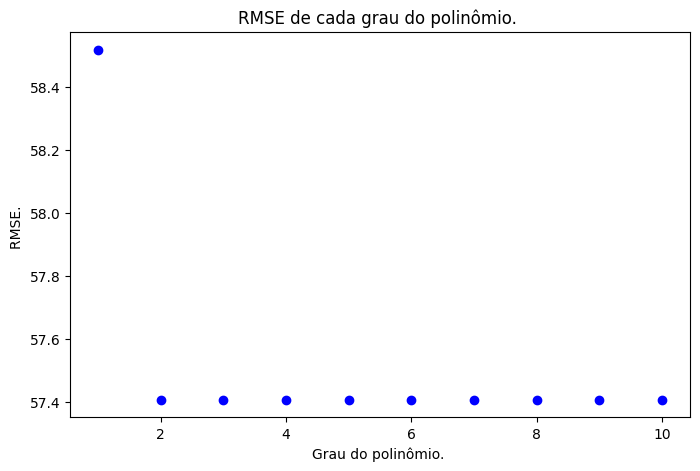

In [28]:
grau, lamb, rmseteste, rmsetreino = zip(*(dados))
plt.figure(figsize=(8,5))
plt.xlabel("Grau do polinômio. ")
plt.ylabel("RMSE. ")
plt.title("RMSE de cada grau do polinômio. ")
plt.scatter(grau, rmsetreino, label="RMSE médio de cada grau do polinômio no treino.", color="blue")
plt.show()

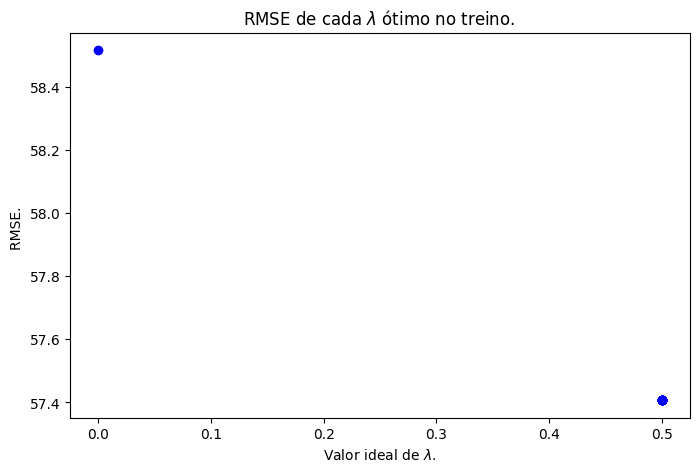

In [24]:
plt.figure(figsize=(8,5))
plt.xlabel(r"Valor ideal de $\lambda$. ")
plt.ylabel("RMSE. ")
plt.title(r"RMSE de cada $\lambda$ ótimo no treino. ")
plt.scatter(lamb, rmsetreino, color="blue")
plt.show()

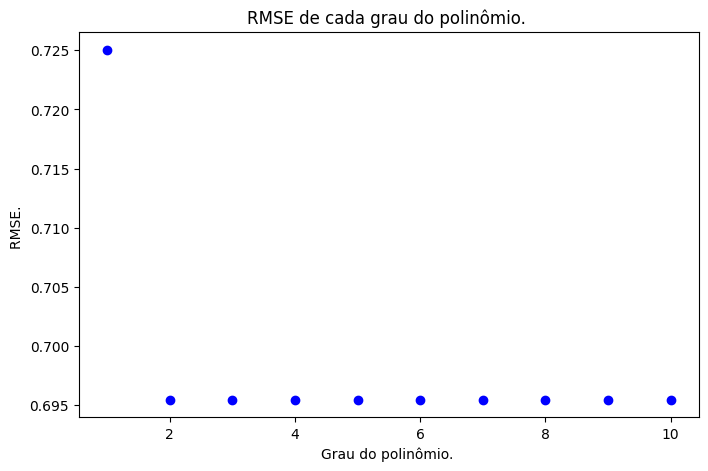

In [27]:
grau, lamb, rmseteste, rmsetreino = zip(*(dados))
plt.figure(figsize=(8,5))
plt.xlabel("Grau do polinômio. ")
plt.ylabel("RMSE. ")
plt.title("RMSE de cada grau do polinômio. ")
plt.scatter(grau, rmseteste, label="RMSE médio de cada grau do polinômio no teste.", color="blue")
plt.show()

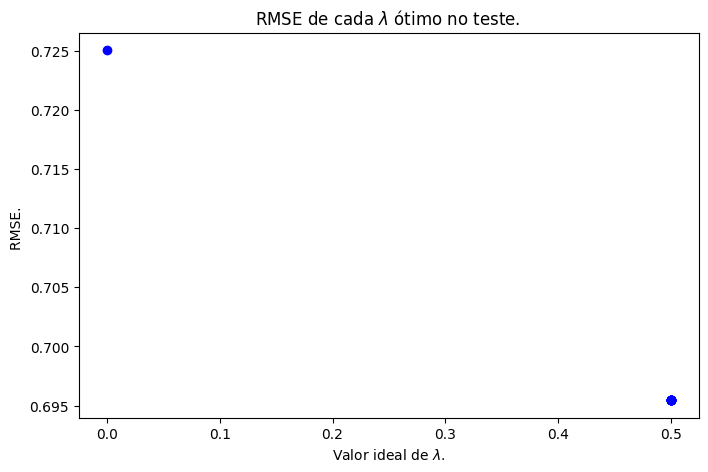

In [29]:
plt.figure(figsize=(8,5))
plt.xlabel(r"Valor ideal de $\lambda$. ")
plt.ylabel("RMSE. ")
plt.title(r"RMSE de cada $\lambda$ ótimo no teste. ")
plt.scatter(lamb, rmseteste, color="blue")
plt.show()

Como podemos ver pelos gráficos, o lambda ótimo em quase todos os casos é $\lambda=0.5$, o grau ótimo do polinômio variou mas o menor rmse registrado foi 7.